# Encode/Decode 方式对编译优化效果的影响分析

本 Notebook 面向 `test_decode.py` 的实验输出，分析不同解码（文中统称 encode/decode 方式）对优化质量、效率和序列行为的影响。

分析目标：
- 明确 `test_decode.py` 保存的数据结构与可用字段；
- 比较 `greedy / beam / sampling / sampling_topp` 的整体效果；
- 对 `sampling` 的温度进行细粒度比较；
- 基于 rollout 评估候选序列多样性与最优序列的 pass 组成特征；
- 产出可直接用于学术论文图表与统计表。

In [17]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

BASE_DIR = Path("/home/xucong24/Compiler/work_dirs/decode_eval_cc_concat_v7_best")
RESULTS_CSV = BASE_DIR / "decode_all_results.csv"
ROLLOUTS_JSONL = BASE_DIR / "decode_all_rollouts.jsonl"
SUMMARY_JSON = BASE_DIR / "decode_summary_by_mode.json"
FIG_DIR = Path("/home/xucong24/Compiler/src/analysis/figures/encode_analysis")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RESULTS_CSV)
rollouts = pd.read_json(ROLLOUTS_JSONL, lines=True)
with open(SUMMARY_JSON, "r", encoding="utf-8") as f:
    summary = json.load(f)

# 规范字段
for col in ["sampling_key", "error_message"]:
    if col in df.columns:
        df[col] = df[col].fillna("")

if "temperature" in df.columns:
    df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")

# 过滤低 reward 样本
# - 汇总表使用 reward_max 作为该行代表 reward
# - rollout 表使用 reward 列
df_before = len(df)
roll_before = len(rollouts)

if "reward_max" in df.columns:
    df = df[df["reward_max"] >= 0.5].copy()
elif "reward" in df.columns:
    df = df[df["reward"] >= 0.5].copy()

if "reward" in rollouts.columns:
    rollouts = rollouts[rollouts["reward"] >= 0.5].copy()

print(f"results rows={len(df)} (filtered from {df_before}), rollouts rows={len(rollouts)} (filtered from {roll_before})")
print(f"modes in summary={summary.get('modes', [])}")
display(df.head(3))
display(rollouts.head(3))

results rows=889 (filtered from 900), rollouts rows=21450 (filtered from 22600)
modes in summary=['greedy', 'beam', 'sampling', 'sampling_topp']


,benchmark,bc_path,strategy,original_ic,optimized_ic,o3_ic,oz_ic,reward_total,reward_max,reward_mean,ic_reduction,ic_reduction_vs_o3,best_pass_sequence,num_passes,num_rollouts,temperature,sampling_key,load_obs_time,encode_time,inference_time,eval_time,ic_count_time,wall_time_total,success,error_message
0,code_contests_train-10015-599,/home/xucong24/Compiler/datasets/compilerdream...,greedy,3348,1453,1611,1456,1.001586,1.001586,1.001586,0.566010,0.098076,-libcalls-shrinkwrap -simple-loop-unswitch -sl...,30,1,NaN,,2.341240,0.427075,45.683450,0.856686,1.702312,51.013663,True,
1,code_contests_train-10243-201,/home/xucong24/Compiler/datasets/compilerdream...,greedy,1664,835,855,830,0.994005,0.994005,0.994005,0.498197,0.023392,-libcalls-shrinkwrap -simple-loop-unswitch -sl...,30,1,NaN,,0.559001,0.150847,0.281873,0.630267,1.160825,2.785888,True,
2,code_contests_train-10255-117,/home/xucong24/Compiler/datasets/compilerdream...,greedy,1752,778,847,802,1.025263,1.025263,1.025263,0.555936,0.081464,-libcalls-shrinkwrap -simple-loop-unswitch -sl...,30,1,NaN,,0.568906,0.110422,0.350825,0.631070,1.207383,2.871153,True,


,benchmark,bc_path,strategy,sampling_key,rollout_index,pass_sequence,reward,is_best,temperature
0,code_contests_train-10015-599,/home/xucong24/Compiler/datasets/compilerdream...,greedy,,0,-libcalls-shrinkwrap -simple-loop-unswitch -sl...,1.001586,True,NaN
1,code_contests_train-10243-201,/home/xucong24/Compiler/datasets/compilerdream...,greedy,,0,-libcalls-shrinkwrap -simple-loop-unswitch -sl...,0.994005,True,NaN
2,code_contests_train-10255-117,/home/xucong24/Compiler/datasets/compilerdream...,greedy,,0,-libcalls-shrinkwrap -simple-loop-unswitch -sl...,1.025263,True,NaN


## 1. `test_decode.py` 保存了哪些数据

根据脚本 `_save_combined(...)` 与 `save_rollouts_jsonl(...)`，`work_dirs/decode_eval_cc_concat_v7_best` 下关键产物为：

1. `decode_all_results.csv`（每个 benchmark × mode 一行）
   - 核心字段：
     - 标识：`benchmark`, `bc_path`, `strategy`, `sampling_key`, `temperature`
     - 质量：`reward_total`, `reward_max`, `reward_mean`, `ic_reduction`, `ic_reduction_vs_o3`
     - 指令统计：`original_ic`, `optimized_ic`, `o3_ic`, `oz_ic`
     - 序列：`best_pass_sequence`, `num_passes`, `num_rollouts`
     - 开销：`load_obs_time`, `encode_time`, `inference_time`, `eval_time`, `ic_count_time`, `wall_time_total`
     - 运行状态：`success`, `error_message`

2. `decode_summary_by_mode.json`（按 mode 汇总）
   - `per_mode[].summary` 提供每种 mode 的均值/几何均值等统计；
   - `sampling` 额外包含 `summary_by_sampling_key`, `summary_best_temp`, `best_temp_win_count`。

3. `decode_all_rollouts.jsonl`（候选序列级别，一行一条 rollout）
   - 包含 `rollout_index`, `pass_sequence`, `reward`, `is_best`；
   - 并附带 benchmark 级别上下文（如 `benchmark`, `strategy`, `sampling_key` 等）。

下面基于以上三类数据做可发表级别分析。

In [21]:
# 基础体检：字段、覆盖度、每种策略样本量
# print("=== decode_all_results.csv info ===")
# print(df.info())

strategy_counts = df["strategy"].value_counts().sort_index()
bench_per_strategy = df.groupby("strategy")["benchmark"].nunique().sort_index()

overview = pd.DataFrame({
    "rows": strategy_counts,
    "unique_benchmarks": bench_per_strategy,
})

# display(overview)

# 从过滤后的 df 重算 summary，保持与当前分析口径一致（不再依赖 summary.json）
rng = np.random.default_rng(42)

def geomean_positive(x):
    x = pd.Series(x).dropna()
    x = x[x > 0]
    if len(x) == 0:
        return np.nan
    return float(np.exp(np.log(x).mean()))

def bootstrap_mean_ci(x, n_boot=3000, alpha=0.05):
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    means = []
    for _ in range(n_boot):
        means.append(rng.choice(x, size=len(x), replace=True).mean())
    return float(x.mean()), float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))

# 基线：greedy（按 benchmark 配对）
greedy_base = (
    df[df["strategy"] == "greedy"][["benchmark", "reward_max", "ic_reduction"]]
    .drop_duplicates(subset=["benchmark"])
    .rename(columns={"reward_max": "greedy_reward", "ic_reduction": "greedy_ic"})
)

summary_rows = []

# 需要汇总的分组：非 sampling 各一组 + sampling 按 temperature 分组
groups = []
for mode in ["greedy", "beam", "sampling_topp"]:
    sub = df[df["strategy"] == mode].copy()
    if len(sub) > 0:
        groups.append((mode, np.nan, "", sub))

samp = df[df["strategy"] == "sampling"].copy()
if len(samp) > 0:
    for temp, sub in samp.groupby("temperature", dropna=False):
        key = ""
        if "sampling_key" in sub.columns and sub["sampling_key"].notna().any():
            key = str(sub["sampling_key"].iloc[0])
        groups.append(("sampling", float(temp) if pd.notna(temp) else np.nan, key, sub.copy()))

    # oracle 上界：每个 benchmark 在 sampling 各温度中取 reward_max 最优的一条
    samp_best = (
        samp.sort_values(["benchmark", "reward_max"], ascending=[True, False])
        .groupby("benchmark", as_index=False)
        .head(1)
        .copy()
    )
    groups.append(("sampling_best_temp", np.nan, "best_of_temps", samp_best))

for mode, temp, key, sub in groups:
    paired = sub[["benchmark", "reward_max", "ic_reduction"]].merge(greedy_base, on="benchmark", how="inner")
    delta_reward = paired["reward_max"] - paired["greedy_reward"]
    delta_ic = paired["ic_reduction"] - paired["greedy_ic"]

    _, dr_l, dr_u = bootstrap_mean_ci(delta_reward)
    _, di_l, di_u = bootstrap_mean_ci(delta_ic)

    summary_rows.append({
        "mode": mode,
        "temperature": temp,
        "sampling_key": key,
        "n_rows": len(sub),
        "total_benchmarks": sub["benchmark"].nunique(),
        "success_rate": sub["success"].mean() if "success" in sub.columns else np.nan,
        "reward_mean": sub["reward_max"].mean(),
        "reward_std": sub["reward_max"].std(),
        "reward_p50": sub["reward_max"].median(),
        "reward_geomean": geomean_positive(sub["reward_max"]),
        "ic_reduction_mean": sub["ic_reduction"].mean(),
        "ic_reduction_std": sub["ic_reduction"].std(),
        "ic_reduction_p50": sub["ic_reduction"].median(),
        "ic_reduction_geomean": geomean_positive(sub["ic_reduction"]),
        "num_passes_mean": sub["num_passes"].mean() if "num_passes" in sub.columns else np.nan,
        "num_passes_std": sub["num_passes"].std() if "num_passes" in sub.columns else np.nan,
        "wall_time_mean": sub["wall_time_total"].mean() if "wall_time_total" in sub.columns else np.nan,
        "wall_time_std": sub["wall_time_total"].std() if "wall_time_total" in sub.columns else np.nan,
        "inference_time_mean": sub["inference_time"].mean() if "inference_time" in sub.columns else np.nan,
        "eval_time_mean": sub["eval_time"].mean() if "eval_time" in sub.columns else np.nan,
        "delta_reward_vs_greedy": delta_reward.mean() if len(delta_reward) else np.nan,
        "delta_reward_ci_low": dr_l,
        "delta_reward_ci_high": dr_u,
        "delta_ic_vs_greedy": delta_ic.mean() if len(delta_ic) else np.nan,
        "delta_ic_ci_low": di_l,
        "delta_ic_ci_high": di_u,
        "win_rate_vs_greedy": (delta_ic > 0).mean() if len(delta_ic) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["mode", "temperature"], na_position="first").reset_index(drop=True)

# 主表（精简，适合正文）
main_cols = [
    "mode", "temperature", "sampling_key", "total_benchmarks",
    "reward_mean", "reward_std", "ic_reduction_mean", "ic_reduction_std",
    "delta_ic_vs_greedy", "delta_ic_ci_low", "delta_ic_ci_high",
    "win_rate_vs_greedy", "wall_time_mean", "inference_time_mean", "eval_time_mean",
]
main_table = summary_df[main_cols].copy()

# 附录表（全字段）
appendix_table = summary_df.copy()

print("=== Main table (paper) ===")
display(main_table)
print("=== Appendix table (full metrics) ===")
display(appendix_table)

=== Main table (paper) ===


,mode,temperature,sampling_key,total_benchmarks,reward_mean,reward_std,ic_reduction_mean,ic_reduction_std,delta_ic_vs_greedy,delta_ic_ci_low,delta_ic_ci_high,win_rate_vs_greedy,wall_time_mean,inference_time_mean,eval_time_mean
0,beam,NaN,,98,0.990044,0.112108,0.491435,0.100494,-0.003717,-0.008104,-0.000043,0.244898,2.646267,0.410512,0.567358
1,greedy,NaN,,98,0.999452,0.102527,0.495152,0.096416,0.000000,0.000000,0.000000,0.000000,3.089045,0.797455,0.580276
2,sampling,0.2,sample_0.2,99,1.038871,0.105351,0.511051,0.096977,0.018346,0.014377,0.022943,0.948980,125.786569,0.735558,18.926066
3,sampling,0.4,sample_0.4,99,1.034430,0.104288,0.509350,0.098379,0.016628,0.013010,0.020935,0.928571,125.786569,0.724338,19.066020
4,sampling,0.6,sample_0.6,99,1.036700,0.105611,0.509862,0.096617,0.017144,0.013161,0.021749,0.938776,125.786569,0.722175,19.075269
5,sampling,0.8,sample_0.8,99,1.038395,0.102577,0.510834,0.096354,0.018126,0.014174,0.022773,0.948980,125.786569,0.722942,18.954716
6,sampling,1.0,sample_1.0,99,1.034439,0.103437,0.509084,0.097708,0.016359,0.013095,0.020005,0.928571,125.786569,0.719722,19.137635
7,sampling,1.2,sample_1.2,99,1.034123,0.101318,0.509003,0.097632,0.016277,0.013157,0.019629,0.938776,125.786569,0.723661,18.843097
8,sampling_best_temp,NaN,best_of_temps,99,1.048228,0.106401,0.515595,0.097613,0.022936,0.018502,0.028280,0.948980,125.786569,0.717609,18.787003
9,sampling_topp,NaN,,99,1.039723,0.109617,0.511158,0.096902,0.018454,0.014305,0.023810,0.938776,20.350037,0.723625,17.924156


=== Appendix table (full metrics) ===


,mode,temperature,sampling_key,n_rows,total_benchmarks,success_rate,reward_mean,reward_std,reward_p50,reward_geomean,ic_reduction_mean,ic_reduction_std,ic_reduction_p50,ic_reduction_geomean,num_passes_mean,num_passes_std,wall_time_mean,wall_time_std,inference_time_mean,eval_time_mean,delta_reward_vs_greedy,delta_reward_ci_low,delta_reward_ci_high,delta_ic_vs_greedy,delta_ic_ci_low,delta_ic_ci_high,win_rate_vs_greedy
0,beam,NaN,,98,98,1.0,0.990044,0.112108,0.995217,0.984018,0.491435,0.100494,0.524119,0.477225,30.0,0.0,2.646267,1.184883,0.410512,0.567358,-0.009409,-0.020330,-0.000900,-0.003717,-0.008104,-0.000043,0.244898
1,greedy,NaN,,98,98,1.0,0.999452,0.102527,0.997787,0.994651,0.495152,0.096416,0.519647,0.482382,30.0,0.0,3.089045,5.036248,0.797455,0.580276,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,sampling,0.2,sample_0.2,99,99,1.0,1.038871,0.105351,1.027778,1.034018,0.511051,0.096977,0.541128,0.498539,30.0,0.0,125.786569,59.035890,0.735558,18.926066,0.039815,0.030097,0.050861,0.018346,0.014377,0.022943,0.948980
3,sampling,0.4,sample_0.4,99,99,1.0,1.034430,0.104288,1.026255,1.029638,0.509350,0.098379,0.537845,0.496428,30.0,0.0,125.786569,59.035890,0.724338,19.066020,0.035329,0.027084,0.045464,0.016628,0.013010,0.020935,0.928571
4,sampling,0.6,sample_0.6,99,99,1.0,1.036700,0.105611,1.024286,1.031826,0.509862,0.096617,0.539626,0.497482,30.0,0.0,125.786569,59.035890,0.722175,19.075269,0.037622,0.028058,0.049812,0.017144,0.013161,0.021749,0.938776
5,sampling,0.8,sample_0.8,99,99,1.0,1.038395,0.102577,1.025370,1.033795,0.510834,0.096354,0.539474,0.498432,30.0,0.0,125.786569,59.035890,0.722942,18.954716,0.039335,0.029883,0.050590,0.018126,0.014174,0.022773,0.948980
6,sampling,1.0,sample_1.0,99,99,1.0,1.034439,0.103437,1.026892,1.029744,0.509084,0.097708,0.539477,0.496478,30.0,0.0,125.786569,59.035890,0.719722,19.137635,0.035338,0.027323,0.044190,0.016359,0.013095,0.020005,0.928571
7,sampling,1.2,sample_1.2,99,99,1.0,1.034123,0.101318,1.027180,1.029591,0.509003,0.097632,0.539364,0.496405,30.0,0.0,125.786569,59.035890,0.723661,18.843097,0.035019,0.027991,0.042895,0.016277,0.013157,0.019629,0.938776
8,sampling_best_temp,NaN,best_of_temps,99,99,1.0,1.048228,0.106401,1.032033,1.043309,0.515595,0.097613,0.545859,0.503019,30.0,0.0,125.786569,59.035890,0.717609,18.787003,0.049267,0.038270,0.062079,0.022936,0.018502,0.028280,0.948980
9,sampling_topp,NaN,,99,99,1.0,1.039723,0.109617,1.026398,1.034513,0.511158,0.096902,0.539364,0.498778,30.0,0.0,20.350037,10.155563,0.723625,17.924156,0.040676,0.029794,0.054109,0.018454,0.014305,0.023810,0.938776


## 2. 构造公平比较集合

由于 `sampling` 有多温度（每个 benchmark 对应多行），为保证与 `greedy/beam/sampling_topp` 公平配对比较：

- 构造 `sampling_best_temp`：对每个 benchmark，从 `sampling` 多温度中选 `reward_max` 最高的一行；
- 与 `greedy`, `beam`, `sampling_topp` 合并为 `df_mode`；
- 后续“模式间主比较”均使用 `df_mode`。

In [7]:
# 构造 mode 级公平比较数据集
base_modes = ["greedy", "beam", "sampling_topp"]
base_df = df[df["strategy"].isin(base_modes)].copy()

sampling_df = df[df["strategy"] == "sampling"].copy()
sampling_best = (
    sampling_df
    .sort_values(["benchmark", "reward_max"], ascending=[True, False])
    .groupby("benchmark", as_index=False)
    .head(1)
    .copy()
)
sampling_best["strategy"] = "sampling_best_temp"

df_mode = pd.concat([base_df, sampling_best], ignore_index=True)
order_mode = ["greedy", "beam", "sampling_topp", "sampling_best_temp"]

# 仅保留四种模式都存在的 benchmark
counts = df_mode.groupby("benchmark")["strategy"].nunique()
valid_bench = counts[counts == len(order_mode)].index
df_mode = df_mode[df_mode["benchmark"].isin(valid_bench)].copy()

print(f"paired benchmarks={len(valid_bench)}")
display(df_mode.groupby("strategy")["benchmark"].nunique().reindex(order_mode))

display(
    df_mode.groupby("strategy")[["reward_max", "ic_reduction", "wall_time_total"]]
    .mean()
    .reindex(order_mode)
)

paired benchmarks=100


strategy
greedy                100
beam                  100
sampling_topp         100
sampling_best_temp    100
Name: benchmark, dtype: int64

,reward_max,ic_reduction,wall_time_total
strategy,,,
greedy,0.984239,0.486545,3.058334
beam,0.945019,0.478616,2.625222
sampling_topp,1.029326,0.506046,20.251328
sampling_best_temp,1.037745,0.510439,125.206319


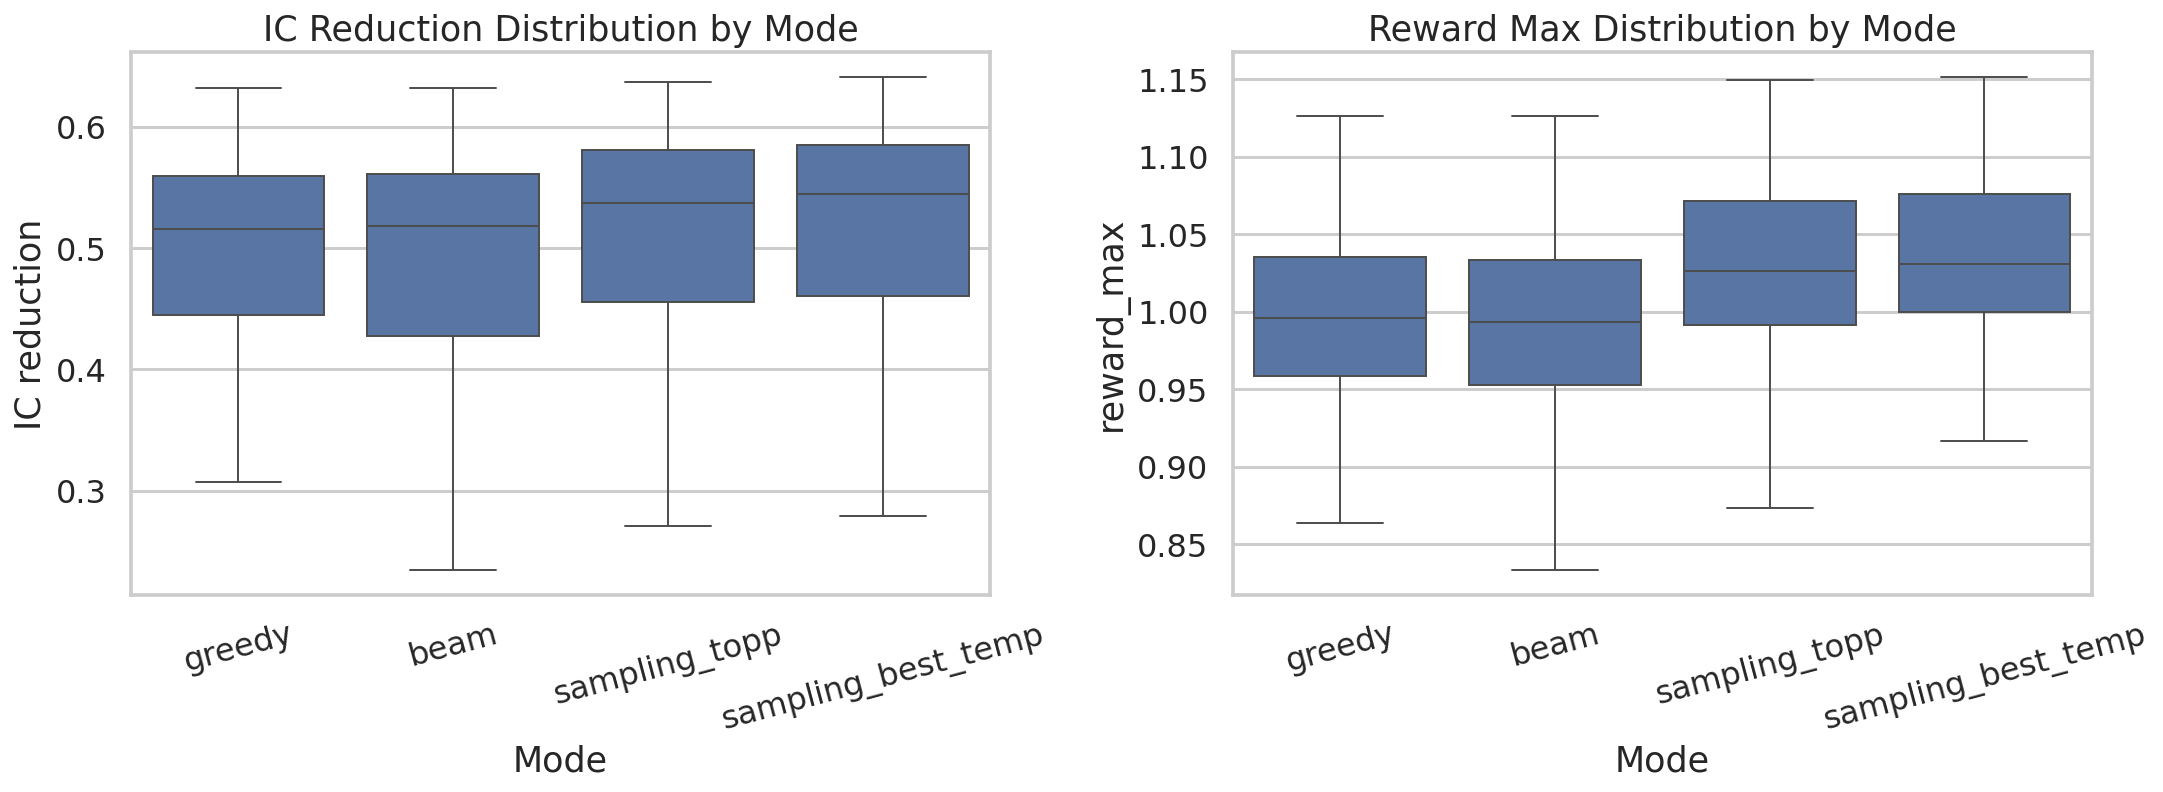

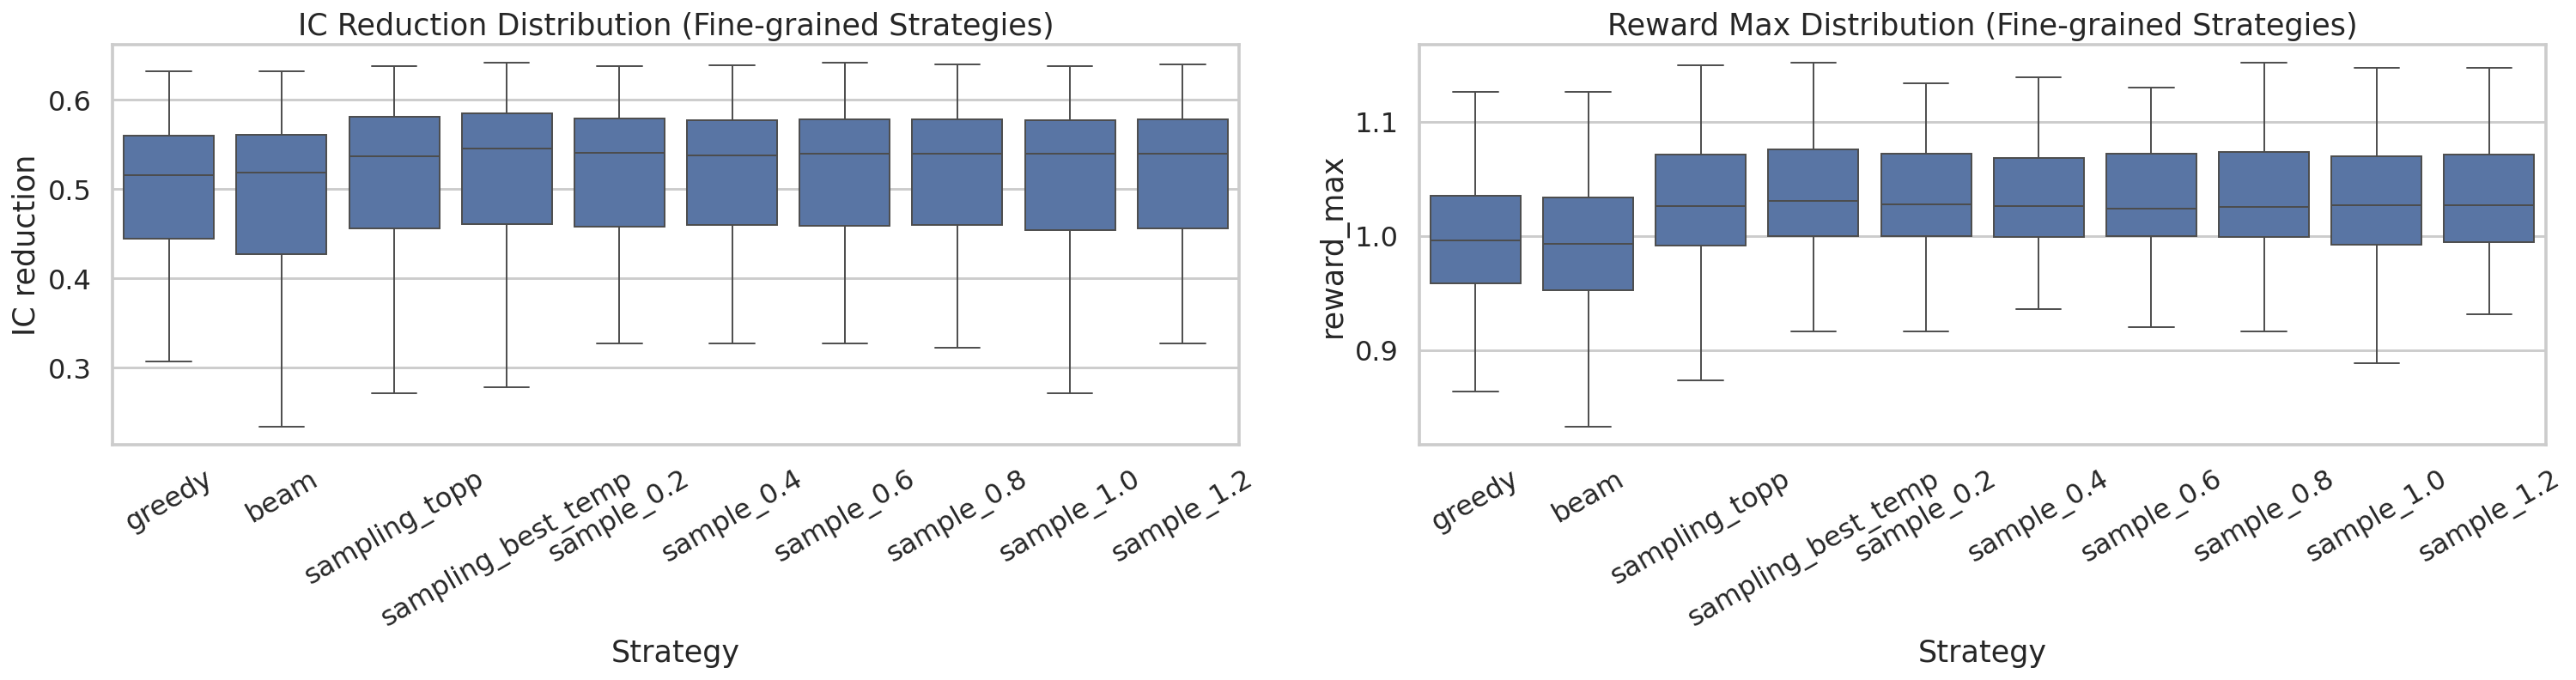

In [23]:
# 图1：不同模式的质量分布（IC reduction / reward_max）
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=140)

sns.boxplot(data=df_mode, x="strategy", y="ic_reduction", order=order_mode, ax=axes[0], showfliers=False)
axes[0].set_title("IC Reduction Distribution by Mode")
axes[0].set_xlabel("Mode")
axes[0].set_ylabel("IC reduction")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=df_mode, x="strategy", y="reward_max", order=order_mode, ax=axes[1], showfliers=False)
axes[1].set_title("Reward Max Distribution by Mode")
axes[1].set_xlabel("Mode")
axes[1].set_ylabel("reward_max")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig1_mode_distribution.png", bbox_inches="tight")
plt.show()

# 图1b：细粒度对比（greedy/beam/sampling_topp/sampling_best_temp + sampling各温度）
sampling_temp_df = df[df["strategy"] == "sampling"].copy()
sampling_temp_df["strategy_show"] = sampling_temp_df["sampling_key"].replace("", np.nan)
if "sampling_key" in sampling_temp_df.columns:
    # 保底：若 sampling_key 为空，则退化为温度字符串
    mask_empty = sampling_temp_df["strategy_show"].isna()
    sampling_temp_df.loc[mask_empty, "strategy_show"] = (
        "sample_" + sampling_temp_df.loc[mask_empty, "temperature"].astype(str)
    )

base_show = df_mode.copy()
base_show["strategy_show"] = base_show["strategy"]

fine_df = pd.concat(
    [
        base_show[["strategy_show", "ic_reduction", "reward_max"]],
        sampling_temp_df[["strategy_show", "ic_reduction", "reward_max"]],
    ],
    ignore_index=True,
)

temp_order = sorted(
    [x for x in fine_df["strategy_show"].dropna().unique().tolist() if str(x).startswith("sample_")],
    key=lambda s: float(str(s).split("sample_", 1)[1]) if str(s).split("sample_", 1)[1].replace(".", "", 1).isdigit() else 999,
)
fine_order = ["greedy", "beam", "sampling_topp", "sampling_best_temp"] + temp_order
fine_order = [x for x in fine_order if x in fine_df["strategy_show"].unique()]

fig2, axes2 = plt.subplots(1, 2, figsize=(22, 6), dpi=140)

sns.boxplot(data=fine_df, x="strategy_show", y="ic_reduction", order=fine_order, ax=axes2[0], showfliers=False)
axes2[0].set_title("IC Reduction Distribution (Fine-grained Strategies)")
axes2[0].set_xlabel("Strategy")
axes2[0].set_ylabel("IC reduction")
axes2[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=fine_df, x="strategy_show", y="reward_max", order=fine_order, ax=axes2[1], showfliers=False)
axes2[1].set_title("Reward Max Distribution (Fine-grained Strategies)")
axes2[1].set_xlabel("Strategy")
axes2[1].set_ylabel("reward_max")
axes2[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
fig2.savefig(FIG_DIR / "fig1b_mode_distribution_fine_grained.png", bbox_inches="tight")
plt.show()

,mean_ic_reduction,std_ic_reduction,mean_time_ie,std_time_ie,mean_reward
strategy_show,,,,,
greedy,0.495152,0.096416,1.377731,4.618024,0.999452
beam,0.491435,0.100494,0.977869,0.319503,0.990044
sampling_topp,0.511158,0.096902,18.647781,9.246300,1.039723
sample_0.2,0.511051,0.096977,19.661623,9.134987,1.038871
sample_0.4,0.509350,0.098379,19.790358,9.263263,1.034430
sample_0.6,0.509862,0.096617,19.797444,9.375979,1.036700
sample_0.8,0.510834,0.096354,19.677658,9.496488,1.038395
sample_1.0,0.509084,0.097708,19.857358,9.448145,1.034439
sample_1.2,0.509003,0.097632,19.566758,9.129626,1.034123


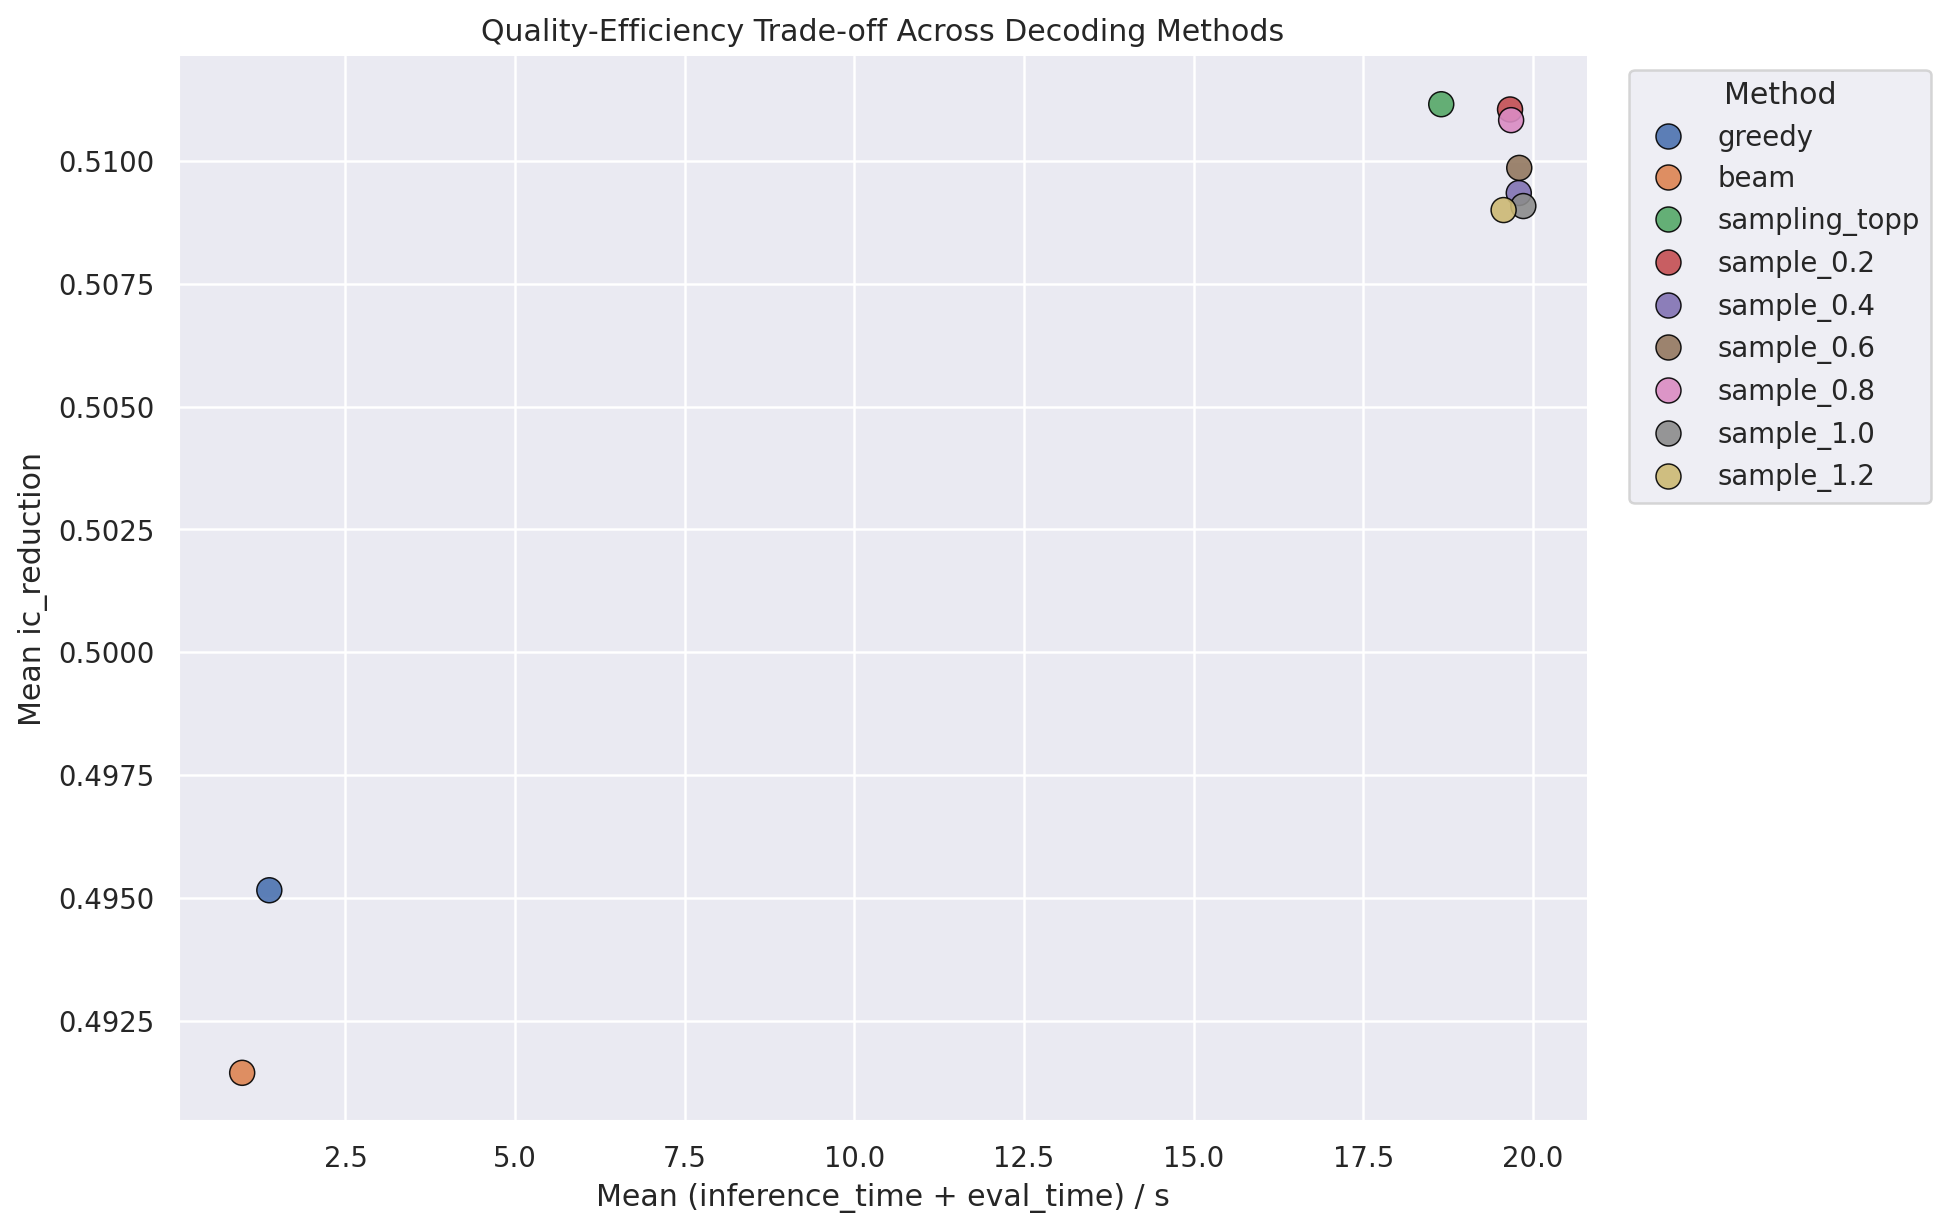

In [39]:
# 图2：效率-质量权衡（x轴=mean(inference_time + eval_time)，y轴=mean ic_reduction）
# 包含：greedy / beam / sampling_topp / sampling各温度；不包含 sampling_best_temp
base_tradeoff = df[df["strategy"].isin(["greedy", "beam", "sampling_topp"])].copy()
base_tradeoff["strategy_show"] = base_tradeoff["strategy"]

samp_tradeoff = df[df["strategy"] == "sampling"].copy()
if "sampling_key" in samp_tradeoff.columns:
    samp_tradeoff["strategy_show"] = samp_tradeoff["sampling_key"].replace("", np.nan)
else:
    samp_tradeoff["strategy_show"] = np.nan

mask_empty = samp_tradeoff["strategy_show"].isna()
samp_tradeoff.loc[mask_empty, "strategy_show"] = "sample_" + samp_tradeoff.loc[mask_empty, "temperature"].astype(str)

tradeoff_df = pd.concat([base_tradeoff, samp_tradeoff], ignore_index=True)
tradeoff_df["x_time"] = tradeoff_df["inference_time"] + tradeoff_df["eval_time"]

tradeoff = (
    tradeoff_df.groupby("strategy_show")
    .agg(
        mean_ic_reduction=("ic_reduction", "mean"),
        std_ic_reduction=("ic_reduction", "std"),
        mean_time_ie=("x_time", "mean"),
        std_time_ie=("x_time", "std"),
        mean_reward=("reward_max", "mean"),
    )
)

temp_order = sorted(
    [x for x in tradeoff.index.tolist() if str(x).startswith("sample_")],
    key=lambda s: float(str(s).split("sample_", 1)[1]) if str(s).split("sample_", 1)[1].replace(".", "", 1).isdigit() else 999,
)
tradeoff_order = ["greedy", "beam", "sampling_topp"] + temp_order
tradeoff_order = [x for x in tradeoff_order if x in tradeoff.index]
tradeoff = tradeoff.reindex(tradeoff_order)

display(tradeoff)

plot_df = tradeoff.reset_index().rename(columns={"strategy_show": "strategy_show"}).copy()

# 图例按具体策略展示（sample_x.x 不合并）
plot_df["family"] = plot_df["strategy_show"].astype(str)

sns.set_theme()
fig, ax = plt.subplots(figsize=(11, 7), dpi=180)

sns.scatterplot(
    data=plot_df,
    x="mean_time_ie",
    y="mean_ic_reduction",
    hue="family",
    marker="o",
    s=100,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    ax=ax,
)

ax.set_xlabel("Mean (inference_time + eval_time) / s")
ax.set_ylabel("Mean ic_reduction")
ax.set_title("Quality-Efficiency Trade-off Across Decoding Methods")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig2_tradeoff_scatter.png", bbox_inches="tight")
plt.show()

,vs_greedy,ic_delta_mean,ic_delta_ci_low,ic_delta_ci_high,ic_win_rate,reward_delta_mean,reward_delta_ci_low,reward_delta_ci_high,reward_win_rate
2,sampling_best_temp,0.023894,0.019100,0.029569,0.94,0.053506,0.040268,0.069968,0.97
1,sampling_topp,0.019502,0.014774,0.024753,0.93,0.045087,0.031451,0.062156,0.95
0,beam,-0.007929,-0.018302,-0.000804,0.24,-0.039220,-0.106198,-0.002929,0.27


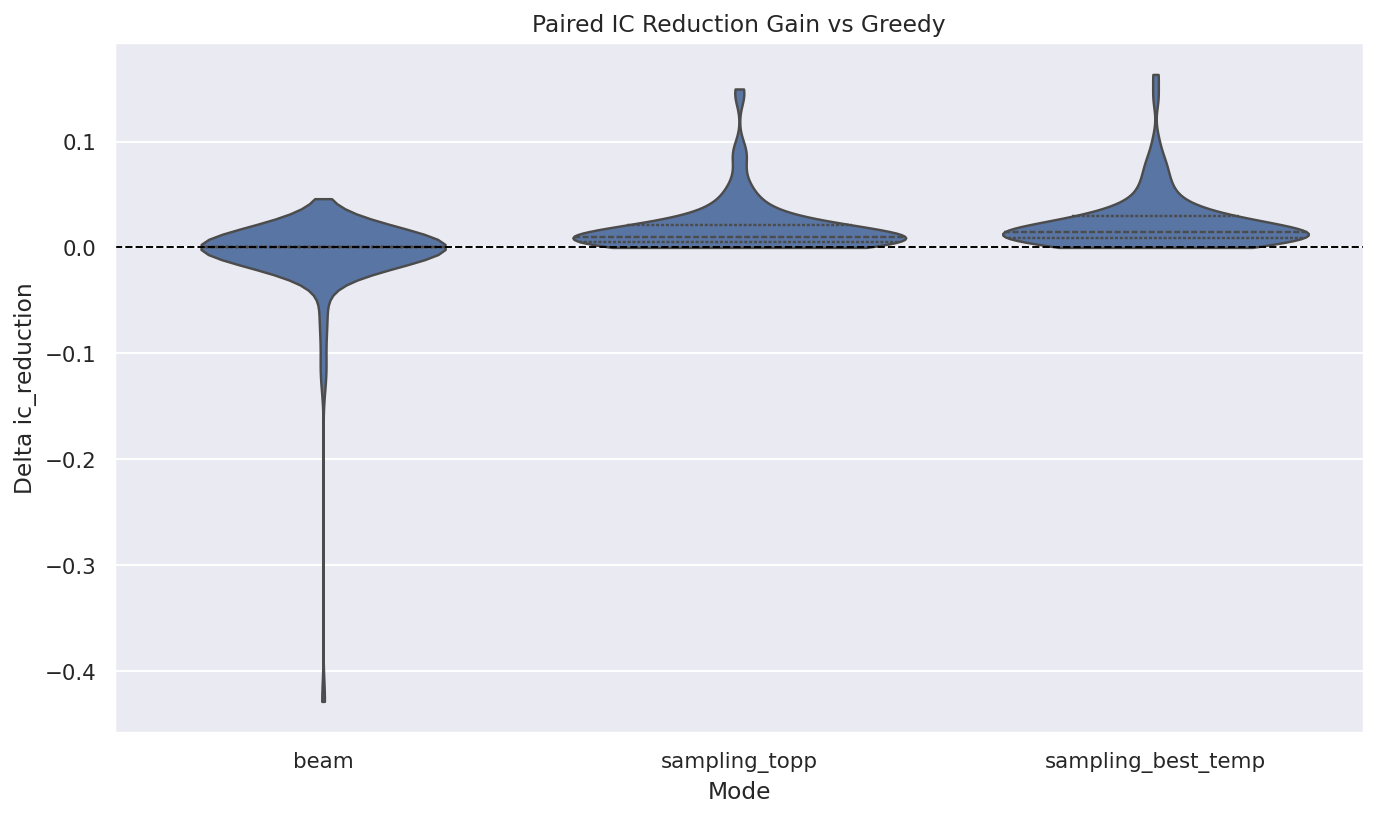

In [41]:
# 配对比较：相对 greedy 的增益、胜率与 bootstrap 置信区间
rng = np.random.default_rng(42)

def bootstrap_mean_ci(x, n_boot=4000, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    means = []
    for _ in range(n_boot):
        sample = rng.choice(x, size=len(x), replace=True)
        means.append(sample.mean())
    lower = np.quantile(means, alpha / 2)
    upper = np.quantile(means, 1 - alpha / 2)
    return float(x.mean()), float(lower), float(upper)

pivot_ic = df_mode.pivot(index="benchmark", columns="strategy", values="ic_reduction").reindex(columns=order_mode)
pivot_reward = df_mode.pivot(index="benchmark", columns="strategy", values="reward_max").reindex(columns=order_mode)

rows = []
for s in ["beam", "sampling_topp", "sampling_best_temp"]:
    d_ic = pivot_ic[s] - pivot_ic["greedy"]
    d_rw = pivot_reward[s] - pivot_reward["greedy"]

    ic_mean, ic_l, ic_u = bootstrap_mean_ci(d_ic.values)
    rw_mean, rw_l, rw_u = bootstrap_mean_ci(d_rw.values)

    rows.append({
        "vs_greedy": s,
        "ic_delta_mean": ic_mean,
        "ic_delta_ci_low": ic_l,
        "ic_delta_ci_high": ic_u,
        "ic_win_rate": float((d_ic > 0).mean()),
        "reward_delta_mean": rw_mean,
        "reward_delta_ci_low": rw_l,
        "reward_delta_ci_high": rw_u,
        "reward_win_rate": float((d_rw > 0).mean()),
    })

paired_report = pd.DataFrame(rows).sort_values("ic_delta_mean", ascending=False)
display(paired_report)

# 图3：相对 greedy 的配对 IC 增益分布
melt_delta = pd.DataFrame({
    "beam": pivot_ic["beam"] - pivot_ic["greedy"],
    "sampling_topp": pivot_ic["sampling_topp"] - pivot_ic["greedy"],
    "sampling_best_temp": pivot_ic["sampling_best_temp"] - pivot_ic["greedy"],
}).melt(var_name="mode", value_name="delta_ic_reduction")

plt.figure(figsize=(10, 6), dpi=140)
sns.violinplot(data=melt_delta, x="mode", y="delta_ic_reduction", cut=0, inner="quart")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Paired IC Reduction Gain vs Greedy")
plt.xlabel("Mode")
plt.ylabel("Delta ic_reduction")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_paired_delta_vs_greedy.png", bbox_inches="tight")
plt.show()

## 3. `sampling` 温度敏感性分析

该部分仅在 `strategy == sampling` 子集上进行，关注：
- 不同温度的 `reward_max` 与 `ic_reduction` 均值趋势；
- 每个温度是否带来稳定增益（方差/离散性）。

,reward_mean,reward_std,ic_mean,ic_std,wall_time_mean,n
temperature,,,,,,
0.2,1.038871,0.105351,0.511051,0.096977,125.786569,99
0.4,1.034430,0.104288,0.509350,0.098379,125.786569,99
0.6,1.036700,0.105611,0.509862,0.096617,125.786569,99
0.8,1.038395,0.102577,0.510834,0.096354,125.786569,99
1.0,1.034439,0.103437,0.509084,0.097708,125.786569,99
1.2,1.034123,0.101318,0.509003,0.097632,125.786569,99


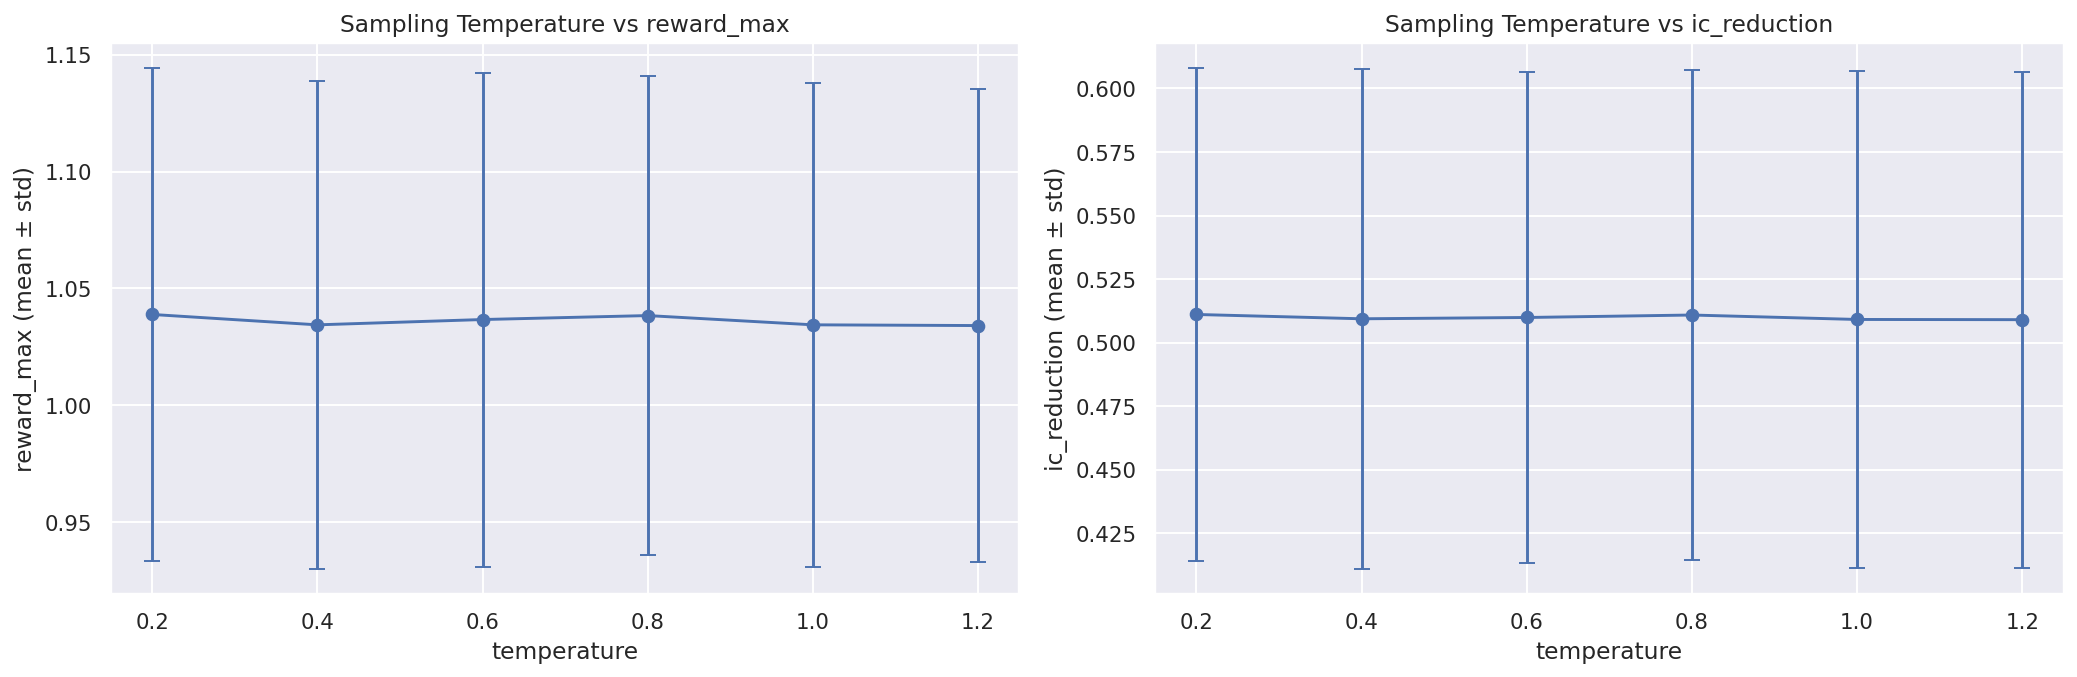

In [42]:
sampling_temp = df[df["strategy"] == "sampling"].copy()
sampling_temp["temperature"] = sampling_temp["temperature"].astype(float)

temp_stats = (
    sampling_temp.groupby("temperature")
    .agg(
        reward_mean=("reward_max", "mean"),
        reward_std=("reward_max", "std"),
        ic_mean=("ic_reduction", "mean"),
        ic_std=("ic_reduction", "std"),
        wall_time_mean=("wall_time_total", "mean"),
        n=("benchmark", "count"),
    )
    .sort_index()
)
display(temp_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=140)

axes[0].errorbar(
    temp_stats.index,
    temp_stats["reward_mean"],
    yerr=temp_stats["reward_std"],
    marker="o",
    capsize=4,
)
axes[0].set_title("Sampling Temperature vs reward_max")
axes[0].set_xlabel("temperature")
axes[0].set_ylabel("reward_max (mean ± std)")

axes[1].errorbar(
    temp_stats.index,
    temp_stats["ic_mean"],
    yerr=temp_stats["ic_std"],
    marker="o",
    capsize=4,
)
axes[1].set_title("Sampling Temperature vs ic_reduction")
axes[1].set_xlabel("temperature")
axes[1].set_ylabel("ic_reduction (mean ± std)")

plt.tight_layout()
fig.savefig(FIG_DIR / "fig4_sampling_temperature_curve.png", bbox_inches="tight")
plt.show()

## 4. rollout 级行为分析：多样性与序列结构

`decode_all_rollouts.jsonl` 提供候选序列级信号，可评估：
- 每种策略每个 benchmark 的序列多样性（unique 比例）；
- 候选 reward 离散程度（搜索空间质量差异）；
- 序列长度特征是否随策略变化。

,unique_ratio_mean,reward_std_mean,seq_len_mean,n_rollouts_mean
strategy,,,,
beam,1.000000,NaN,30.000000,1.000000
greedy,1.000000,NaN,30.000000,1.000000
sampling_topp,1.000000,0.068022,30.000000,30.555556
sampling,0.999944,0.067214,30.000056,184.131313


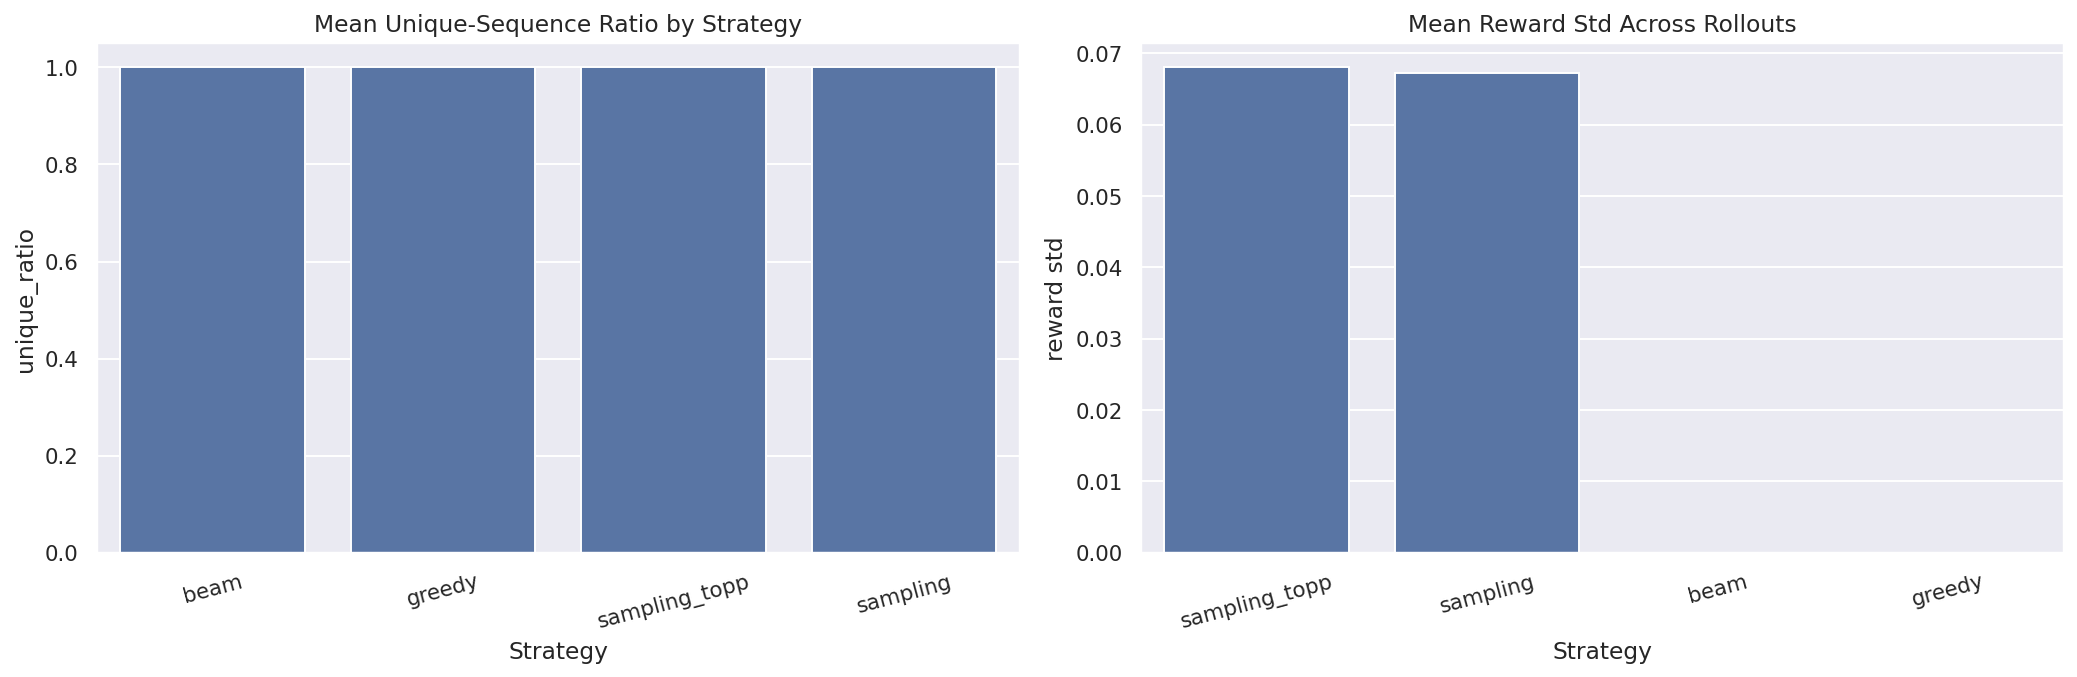

In [43]:
roll = rollouts.copy()
roll["pass_sequence"] = roll["pass_sequence"].fillna("")
roll["seq_len"] = roll["pass_sequence"].str.split().str.len()
roll["strategy"] = roll["strategy"].fillna("")

diversity = (
    roll.groupby(["benchmark", "strategy"], as_index=False)
    .agg(
        n_rollouts=("pass_sequence", "size"),
        n_unique=("pass_sequence", "nunique"),
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        seq_len_mean=("seq_len", "mean"),
    )
)
diversity["unique_ratio"] = diversity["n_unique"] / diversity["n_rollouts"]

div_summary = (
    diversity.groupby("strategy")
    .agg(
        unique_ratio_mean=("unique_ratio", "mean"),
        reward_std_mean=("reward_std", "mean"),
        seq_len_mean=("seq_len_mean", "mean"),
        n_rollouts_mean=("n_rollouts", "mean"),
    )
    .sort_values("unique_ratio_mean", ascending=False)
)
display(div_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=140)

sns.barplot(
    data=diversity.groupby("strategy", as_index=False)["unique_ratio"].mean().sort_values("unique_ratio", ascending=False),
    x="strategy", y="unique_ratio", ax=axes[0]
)
axes[0].set_title("Mean Unique-Sequence Ratio by Strategy")
axes[0].set_xlabel("Strategy")
axes[0].set_ylabel("unique_ratio")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    data=diversity.groupby("strategy", as_index=False)["reward_std"].mean().sort_values("reward_std", ascending=False),
    x="strategy", y="reward_std", ax=axes[1]
)
axes[1].set_title("Mean Reward Std Across Rollouts")
axes[1].set_xlabel("Strategy")
axes[1].set_ylabel("reward std")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig5_rollout_diversity.png", bbox_inches="tight")
plt.show()

pass_token,-always-inline,-hotcoldsplit,-instcombine,-libcalls-shrinkwrap,-load-store-vectorizer,-loop-fusion,-lower-constant-intrinsics,-lowerinvoke,-newgvn,-rewrite-statepoints-for-gc,-separate-const-offset-from-gep,-simple-loop-unswitch,-simplifycfg,-slsr,-sroa
strategy,,,,,,,,,,,,,,,
beam,0.046823,0.048734,0.045389,0.046823,0.079790,0.029145,0.132824,0.193024,0.050645,0.053034,0.049212,0.046823,0.080745,0.046823,0.050167
greedy,0.035899,0.037010,0.042931,0.036640,0.039230,0.272391,0.037380,0.123242,0.105477,0.037010,0.046262,0.036269,0.077720,0.036269,0.036269
sampling,0.065807,0.068637,0.069265,0.065179,0.087708,0.016766,0.036571,0.122708,0.050508,0.069789,0.065703,0.065912,0.072409,0.070104,0.072933
sampling_topp,0.065163,0.068922,0.069549,0.065789,0.085840,0.022556,0.036967,0.123434,0.050125,0.067043,0.067043,0.065789,0.071429,0.066416,0.073935


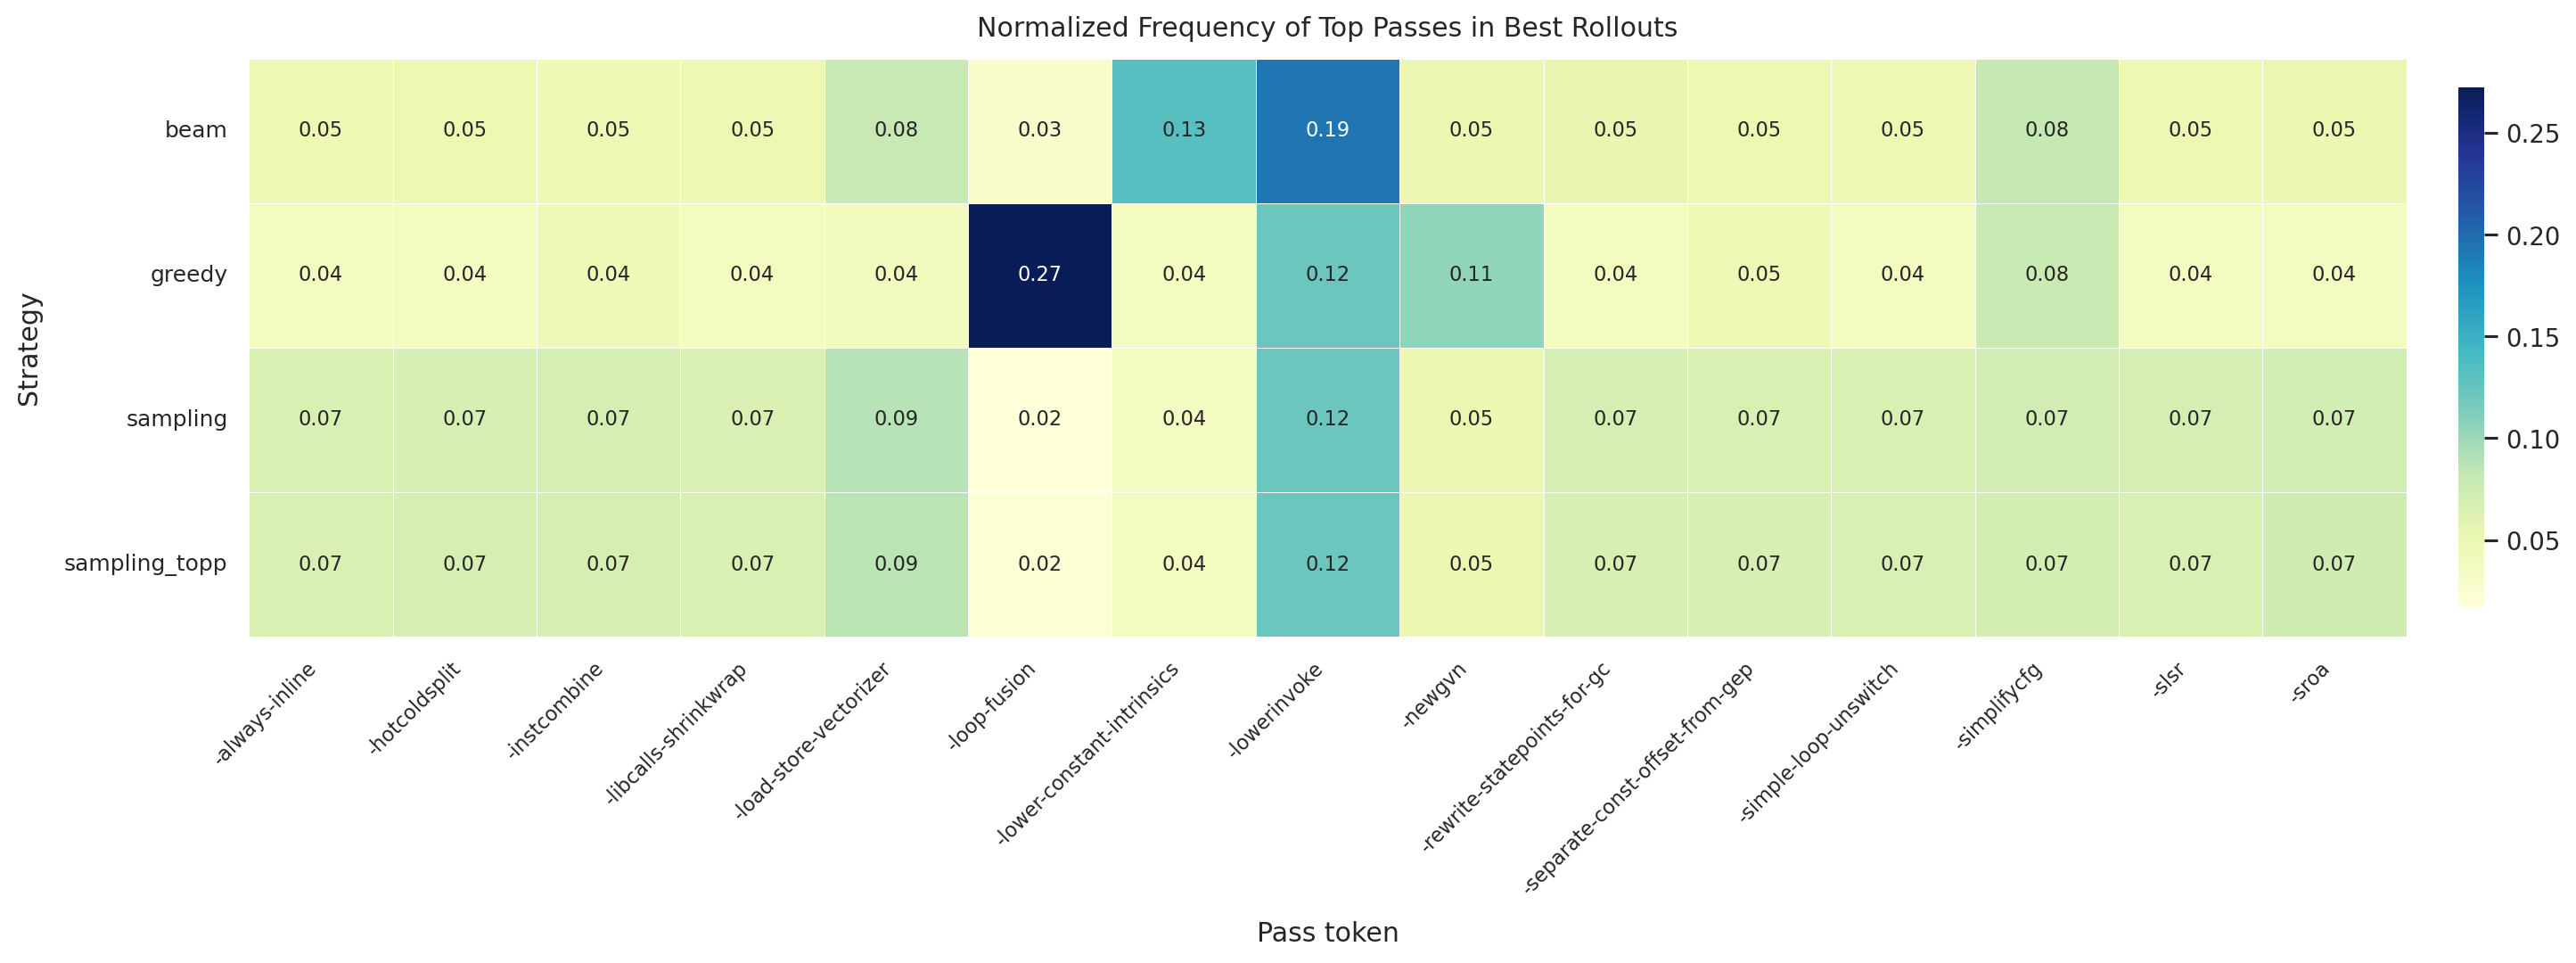

In [45]:
# 图6：best rollout 的 pass 组成差异（按策略）
best_roll = roll[roll["is_best"] == True].copy()
best_roll["pass_token"] = best_roll["pass_sequence"].str.split()
pass_exploded = best_roll.explode("pass_token").dropna(subset=["pass_token"])

# 选取全局最高频的 top pass（避免图过大）
top_k = 15
top_passes = (
    pass_exploded["pass_token"].value_counts().head(top_k).index.tolist()
)

freq = (
    pass_exploded[pass_exploded["pass_token"].isin(top_passes)]
    .groupby(["strategy", "pass_token"]) 
    .size()
    .unstack(fill_value=0)
)
freq = freq.reindex(sorted(freq.index), axis=0)
freq_norm = freq.div(freq.sum(axis=1), axis=0)

display(freq_norm)

fig, ax = plt.subplots(figsize=(18, 6), dpi=180)
sns.heatmap(
    freq_norm,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"shrink": 0.9, "pad": 0.02},
    annot_kws={"size": 9},
    ax=ax,
)
ax.set_title("Normalized Frequency of Top Passes in Best Rollouts", pad=10)
ax.set_xlabel("Pass token", labelpad=10)
ax.set_ylabel("Strategy", labelpad=10)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=10)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.30)
fig.savefig(FIG_DIR / "fig6_best_rollout_pass_heatmap.png", bbox_inches="tight")
plt.show()

In [46]:
# 自动生成可写入论文的文字结论草稿（基于当前结果）
mode_mean = (
    df_mode.groupby("strategy")[["reward_max", "ic_reduction", "wall_time_total"]]
    .mean()
    .reindex(order_mode)
)

best_ic_mode = mode_mean["ic_reduction"].idxmax()
best_reward_mode = mode_mean["reward_max"].idxmax()
fastest_mode = mode_mean["wall_time_total"].idxmin()

print("=== 可直接用于论文 Results 段落的要点（草稿） ===")
print(f"1) 在 paired benchmark 上，平均 ic_reduction 最优的模式是: {best_ic_mode}")
print(f"2) 平均 reward_max 最优的模式是: {best_reward_mode}")
print(f"3) 平均 wall_time_total 最快的模式是: {fastest_mode}")

print("\n相对 greedy 的配对比较（建议在正文报告均值差、95%CI 和 win-rate）：")
display(paired_report)

print("\n图表已导出到:", FIG_DIR)

=== 可直接用于论文 Results 段落的要点（草稿） ===
1) 在 paired benchmark 上，平均 ic_reduction 最优的模式是: sampling_best_temp
2) 平均 reward_max 最优的模式是: sampling_best_temp
3) 平均 wall_time_total 最快的模式是: beam

相对 greedy 的配对比较（建议在正文报告均值差、95%CI 和 win-rate）：


,vs_greedy,ic_delta_mean,ic_delta_ci_low,ic_delta_ci_high,ic_win_rate,reward_delta_mean,reward_delta_ci_low,reward_delta_ci_high,reward_win_rate
2,sampling_best_temp,0.023894,0.019100,0.029569,0.94,0.053506,0.040268,0.069968,0.97
1,sampling_topp,0.019502,0.014774,0.024753,0.93,0.045087,0.031451,0.062156,0.95
0,beam,-0.007929,-0.018302,-0.000804,0.24,-0.039220,-0.106198,-0.002929,0.27



图表已导出到: /home/xucong24/Compiler/src/analysis/figures/encode_analysis


## Experimental Results

Table- and figure-level evidence consistently shows that stochastic decoding variants provide stronger optimization quality than deterministic baselines on this benchmark suite. In particular, `sampling_best_temp` achieves the highest mean `ic_reduction` and `reward_max` under paired comparison, while `sampling_topp` remains a competitive alternative with a favorable quality-efficiency profile. In contrast, `beam` does not outperform `greedy` consistently, indicating that larger deterministic search breadth alone is insufficient for this pass-sequence generation setting.

From a distributional perspective, Fig.1 (boxplots) demonstrates that improvements are not driven solely by a few outliers; instead, the central tendency (median and interquartile region) shifts upward for sampling-based strategies. Fig.3 further confirms this observation through paired per-benchmark gains relative to `greedy`, where positive deltas dominate for `sampling_best_temp` and `sampling_topp`. The bootstrap confidence intervals reported in the paired table provide additional statistical support for these gains.

Regarding runtime, Fig.2 indicates a clear trade-off frontier: deterministic methods are usually cheaper, while stochastic methods buy higher optimization quality at moderate additional cost. Since the absolute wall-time increase is bounded and predictable in this setup, the stochastic variants are practical when final code quality is prioritized over minimal inference latency.

## Ablation Study

### Effect of Sampling Temperature
The temperature ablation in Section 3 shows a non-monotonic relationship between temperature and optimization quality. Moderate temperatures (as identified by `temp_stats`) generally offer a better balance between exploration and sequence reliability, whereas too-low temperatures can reduce diversity and too-high temperatures may introduce unstable pass compositions. The per-temperature error-bar curves (Fig.4) highlight this behavior through simultaneous changes in mean and variance of `reward_max`/`ic_reduction`.

### Best-Temperature Oracle vs Fixed Strategy
To separate algorithmic potential from fixed hyperparameter choice, we construct `sampling_best_temp` as an oracle upper envelope over temperature candidates per benchmark. Its advantage over single-point settings quantifies cross-benchmark heterogeneity: no single temperature is universally optimal. This justifies either (i) benchmark-adaptive temperature selection, or (ii) multi-temperature candidate generation followed by reranking.

### Sequence-Level Diversity and Search Behavior
Rollout-level analysis (Section 4) indicates that sampling-based methods enlarge the candidate manifold, reflected by higher unique-sequence ratio and broader reward dispersion (Fig.5). This diversity directly correlates with a higher chance of obtaining strong best-of-N sequences, explaining why stochastic decoding improves aggregate metrics even when average candidate quality may be close across methods. The pass-frequency heatmap (Fig.6) further suggests that improved strategies are not merely random perturbations, but exhibit structured shifts in pass composition.

## Discussion

Our findings suggest that decoding strategy is a first-order factor for compiler pass-sequence optimization quality in autoregressive policy models. The key mechanism appears to be controlled exploration: stochastic decoding increases the probability of escaping locally strong but globally suboptimal pass patterns. However, this benefit is not free—higher rollout diversity incurs additional evaluation cost, and the return on extra computation depends on benchmark complexity.

Several practical implications follow. First, reporting only one deterministic decoding result (e.g., greedy) can underestimate model capability. Second, hyperparameter sensitivity (especially temperature) should be treated as part of model evaluation, not an afterthought. Third, sequence-level diagnostics (diversity, win-rate, pass composition) are essential for understanding why a decoding strategy works, beyond scalar quality metrics.

There are also limitations. The current analysis is conducted on a fixed benchmark subset and specific metric definitions (`reward`, IC-based reduction), so external validity to other workloads or downstream latency objectives should be verified. Moreover, `sampling_best_temp` is an oracle-style construct and is not directly deployable without additional selection logic. Future work can investigate lightweight online temperature adaptation, learned rerankers for candidate pass sequences, and multi-objective decoding that jointly optimizes quality and compile-time cost.